# Problem 2 — Hardware-Aware Circuit Design for Long-Range CNOT Gate Teleportation

**2026 Quantum Hackathon — Dynamic Circuits (지정문제 4)**

Reference: Bäumer *et al.*, [Efficient Long-Range Entanglement Using Dynamic Circuits](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.5.030339), PRX Quantum **5**, 030339 (2024).

This notebook follows the structure of IBM's [long-range-entanglement](https://quantum.cloud.ibm.com/docs/tutorials/long-range-entanglement) tutorial and addresses:

* **2.1** Two topologies (2D square grid & IBM heavy-hex): ancilla-bus qubit assignment
* **2.2** Unitary vs dynamic long-range CNOT; report gate count, depth, mid-circuit measurements


## Learning outcomes

* Build a **dynamic long-range CNOT (LRCX)** via Bell-pair preparation, Bell-basis measurement, and feed-forward (gate teleportation).
* Build a **unitary SWAP-chain** baseline (Appendix B style) and compare with default transpiler output.
* Map logical system + ancilla-bus qubits onto **square** and **heavy-hex** hardware topologies.
* Profile **two-qubit depth**, **CX/ECR count**, and **mid-circuit measurement** count vs separation `n`.


## Setup


In [87]:
from __future__ import annotations

import math
from collections import deque
from dataclasses import dataclass
from statistics import median

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import IfElseOp, Reset
from qiskit.circuit.classical import expr
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap, Layout, generate_preset_pass_manager
from qiskit.visualization import plot_circuit_layout
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, thermal_relaxation_error
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeBrisbane, FakeMiami

SHOTS = 4096
DISTANCE_DEMO = 6

SEED = 1557
random.seed(SEED)
np.random.seed(SEED)

In [88]:
import sys
from importlib.metadata import PackageNotFoundError, version


def pkg_version(distribution_name: str, import_name: str | None = None) -> str:
    """Return installed package version (pip name + optional import name)."""
    try:
        return version(distribution_name)
    except PackageNotFoundError:
        if import_name is None:
            return "not installed"
        try:
            module = __import__(import_name)
            return getattr(module, "__version__", "not installed")
        except Exception:
            return "not installed"


VERSION_ROWS = [
    ("Python", sys.version.split()[0]),
    ("numpy", pkg_version("numpy")),
    ("pandas", pkg_version("pandas")),
    ("matplotlib", pkg_version("matplotlib")),
    ("qiskit", pkg_version("qiskit")),
    ("qiskit-aer", pkg_version("qiskit-aer", "qiskit_aer")),
    ("qiskit-ibm-runtime", pkg_version("qiskit-ibm-runtime", "qiskit_ibm_runtime")),
]

print("Environment versions")
print("-" * 40)
for name, ver in VERSION_ROWS:
    print(f"{name:22s} {ver}")

Environment versions
----------------------------------------
Python                 3.11.9
numpy                  2.4.6
pandas                 3.0.3
matplotlib             3.10.9
qiskit                 2.4.1
qiskit-aer             0.17.2
qiskit-ibm-runtime     0.47.0


### Noise setup note

The active backend/noise setup is defined in the next two code cells:
- `HardwareNoiseOverrides` / `make_custom_backend` helpers (from `custom_backend.ipynb`)
- `backend_miami`, `backend_yonsei`, `backend_miami_sim`, `backend_yonsei_sim` with `MIAMI_OVERRIDES` / `YONSEI_OVERRIDES`


In [89]:
@dataclass(frozen=True)
class HardwareNoiseOverrides:
    """Controls how the reference backend's hardware noise is modified."""

    t1_scale: float = 1.0
    t2_scale: float = 1.0
    t1_us: float | None = None
    t2_us: float | None = None
    gate_error_scale: float = 1.0
    readout_error_scale: float = 1.0
    reset_error_rate: float = 0.01
    include_thermal_relaxation: bool = True
    include_gate_depolarizing: bool = True
    include_readout_error: bool = True


NOISY_GATE_NAMES = {"id", "sx", "x", "cx", "cz", "ecr", "u", "u1", "u2", "u3", "reset"}


def _clip_probability(value: float, upper: float = 1.0) -> float:
    return min(max(float(value), 0.0), upper)


def _qubit_t1_t2_seconds(reference_backend, qubit: int, overrides: HardwareNoiseOverrides) -> tuple[float, float]:
    qubit_properties = reference_backend.target.qubit_properties
    base_t1 = qubit_properties[qubit].t1
    base_t2 = qubit_properties[qubit].t2

    if base_t1 is None or base_t2 is None:
        raise ValueError(f"Qubit {qubit} does not have T1/T2 calibration data.")

    t1 = overrides.t1_us * 1e-6 if overrides.t1_us is not None else base_t1 * overrides.t1_scale
    t2 = overrides.t2_us * 1e-6 if overrides.t2_us is not None else base_t2 * overrides.t2_scale

    if t1 <= 0 or t2 <= 0:
        raise ValueError("T1 and T2 must be positive.")

    t2 = min(t2, 2 * t1)
    return t1, t2


def _thermal_error_for_qubits(reference_backend, qargs: tuple[int, ...], duration_s: float, overrides: HardwareNoiseOverrides):
    if not qargs:
        return None

    errors = []
    for qubit in qargs:
        t1, t2 = _qubit_t1_t2_seconds(reference_backend, qubit, overrides)
        errors.append(thermal_relaxation_error(t1, t2, duration_s))

    combined = errors[0]
    for error in errors[1:]:
        combined = combined.tensor(error)
    return combined


def build_custom_noise_model(reference_backend, overrides: HardwareNoiseOverrides) -> NoiseModel:
    """Build a robust custom noise model; skip invalid channels safely."""
    noise_model = NoiseModel()
    target = reference_backend.target

    for instruction_name in sorted(target.operation_names):
        if instruction_name not in NOISY_GATE_NAMES:
            continue

        for qargs, properties in target[instruction_name].items():
            if qargs is None or properties is None or len(qargs) == 0:
                continue

            duration_s = properties.duration or 0.0
            gate_error = properties.error or 0.0
            channels = []

            if instruction_name == "reset":
                try:
                    channels.append(depolarizing_error(overrides.reset_error_rate, 1))
                except Exception:
                    pass

            if overrides.include_thermal_relaxation and duration_s > 0:
                try:
                    thermal = _thermal_error_for_qubits(reference_backend, qargs, duration_s, overrides)
                    if thermal is not None:
                        channels.append(thermal)
                except Exception:
                    pass

            if overrides.include_gate_depolarizing and gate_error > 0:
                try:
                    num_qubits = len(qargs)
                    max_depol = (4**num_qubits) / (4**num_qubits - 1)
                    depol_probability = _clip_probability(gate_error * overrides.gate_error_scale, max_depol)
                    if depol_probability > 0:
                        channels.append(depolarizing_error(depol_probability, num_qubits))
                except Exception:
                    pass

            if not channels:
                continue

            try:
                combined_error = channels[0]
                for channel in channels[1:]:
                    combined_error = combined_error.compose(channel)
                noise_model.add_quantum_error(combined_error, [instruction_name], list(qargs), warnings=False)
            except Exception:
                # Some composed channels can be ill-defined for specific calibrated entries.
                continue

    if overrides.include_readout_error and "measure" in target.operation_names:
        for qargs, properties in target["measure"].items():
            if qargs is None or len(qargs) != 1 or properties is None or properties.error is None:
                continue
            readout_p = _clip_probability(properties.error * overrides.readout_error_scale, 1.0)
            ro_err = ReadoutError([[1 - readout_p, readout_p], [readout_p, 1 - readout_p]])
            noise_model.add_readout_error(ro_err, [qargs[0]])

    return noise_model


def make_custom_backend(reference_backend, overrides: HardwareNoiseOverrides) -> AerSimulator:
    noise_model = build_custom_noise_model(reference_backend, overrides)
    simulator = AerSimulator.from_backend(reference_backend)
    simulator.set_options(noise_model=noise_model)
    return simulator


def summarize_backend_t1_t2(reference_backend, qubits: list[int] | None = None) -> dict[str, float]:
    qubit_properties = reference_backend.target.qubit_properties
    qubits = qubits or list(range(len(qubit_properties)))
    t1_values = [qubit_properties[q].t1 * 1e6 for q in qubits if qubit_properties[q].t1 is not None]
    t2_values = [qubit_properties[q].t2 * 1e6 for q in qubits if qubit_properties[q].t2 is not None]
    return {
        "num_qubits": len(qubits),
        "median_t1_us": median(t1_values),
        "median_t2_us": median(t2_values),
        "min_t1_us": min(t1_values),
        "min_t2_us": min(t2_values),
    }


In [90]:
# ------------------------- Fake reference backends + custom noise -------------------------
# Topology snapshots:
#   ibm_miami  -> FakeMiami (2D square)
#   ibm_yonsei -> FakeBrisbane (127-qubit Eagle heavy-hex proxy)
# Noise model: custom_backend.ipynb helpers (T1/T2, gate, readout overrides)

backend_miami = FakeMiami()
backend_yonsei = FakeBrisbane()

for _backend in (backend_miami, backend_yonsei):
    if "if_else" not in _backend.target.operation_names:
        _backend.target.add_instruction(IfElseOp, name="if_else")
    if "reset" not in _backend.target.operation_names:
        _backend.target.add_instruction(Reset, name="reset")

# Tune hardware noise here (scales multiply reference fake-backend calibration).
MIAMI_OVERRIDES = HardwareNoiseOverrides(
    t1_scale=0.5,
    t2_scale=0.5,
    gate_error_scale=1.0,
    readout_error_scale=1.5,
    reset_error_rate=0.01,
)
YONSEI_OVERRIDES = HardwareNoiseOverrides(
    t1_scale=0.5,
    t2_scale=0.5,
    gate_error_scale=1.0,
    readout_error_scale=1.5,
    reset_error_rate=0.01,
)

backend_miami_sim = make_custom_backend(backend_miami, MIAMI_OVERRIDES)
backend_yonsei_sim = make_custom_backend(backend_yonsei, YONSEI_OVERRIDES)

print("ibm_miami reference:", backend_miami.name, summarize_backend_t1_t2(backend_miami))
print("ibm_yonsei reference:", backend_yonsei.name, summarize_backend_t1_t2(backend_yonsei))
print("miami custom sim:", backend_miami_sim)
print("yonsei custom sim:", backend_yonsei_sim)


ibm_miami reference: fake_miami {'num_qubits': 120, 'median_t1_us': 330.217671577652, 'median_t2_us': 241.90913960500842, 'min_t1_us': 24.326998619574102, 'min_t2_us': 38.35023455296686}
ibm_yonsei reference: fake_brisbane {'num_qubits': 127, 'median_t1_us': 231.95327941729698, 'median_t2_us': 150.0402732169314, 'min_t1_us': 9.941314519029863, 'min_t2_us': 17.141797734922665}
miami custom sim: AerSimulator('aer_simulator_from(fake_miami)'
             noise_model=<NoiseModel on ['x', 'measure', 'sx', 'cz', 'id']>)
yonsei custom sim: AerSimulator('aer_simulator_from(fake_brisbane)'
             noise_model=<NoiseModel on ['x', 'measure', 'reset', 'sx', 'id', 'ecr']>)


## Step 1 — Logical long-range CNOT circuits

We use the same gate-teleportation construction as `long-range-entanglement.ipynb`.

* **System qubits:** control `q0`, target `q_{n+1}`
* **Ancilla bus:** `n` intermediate qubits host Bell pairs and parity measurements
* **Dynamic depth:** O(1) in quantum gates (constant number of entangling layers); mid-circuit measurements scale as O(n)


In [91]:
def check_even(n: int) -> int:
    return 1 if n % 2 == 0 else 2


def initialize_circuit(distance: int) -> QuantumCircuit:
    assert distance >= 0
    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    k = int(n / 2)
    allcr = [cr]
    if distance > 1:
        allcr.append(ClassicalRegister(k, name="c1"))
    if distance > 0:
        allcr.append(ClassicalRegister(n - k, name="c2"))
    qc = QuantumCircuit(qr, *allcr, name="LRCX")
    qc.h(0)
    return qc


def prepare_bell_pairs(qc: QuantumCircuit, add_barriers: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    k = int(n / 2)
    if add_barriers:
        qc.barrier()
    x0 = check_even(n)
    if n % 2 != 0:
        qc.cx(0, 1)
    for i in range(k):
        qc.h(x0 + 2 * i)
        qc.cx(x0 + 2 * i, x0 + 2 * i + 1)
    return qc


def reset_measured_ancillas(qc: QuantumCircuit, add_barrier: bool = True) -> QuantumCircuit:
    """Return measured ancilla qubits to |0> (qubits 1..n between control and target)."""
    n = qc.num_qubits - 2
    if n <= 0:
        return qc
    if add_barrier:
        qc.barrier()
    for q in range(1, n + 1):
        qc.reset(q)
    return qc


def measure_bell_basis(qc: QuantumCircuit, add_barriers: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    k = int(n / 2)
    if n > 1:
        _, c1, c2 = qc.cregs
    elif n > 0:
        _, c2 = qc.cregs
    x0 = 1 if n % 2 == 0 else 2
    for i in range(k + 1):
        qc.cx(x0 - 1 + 2 * i, x0 + 2 * i)
    for i in range(1, k + x0):
        qc.h(2 * i + 1 - x0)
    if add_barriers:
        qc.barrier()
    for i in range(k):
        qc.measure(2 * i + x0, c1[i])
    for i in range(1, k + x0):
        qc.measure(2 * i + 1 - x0, c2[i - 1])
    # Dynamic-circuit hardware model: re-initialize ancillas after mid-circuit measurement.
    reset_measured_ancillas(qc, add_barrier=add_barriers)
    return qc


def apply_ffwd_corrections(qc: QuantumCircuit) -> QuantumCircuit:
    control, target = 0, qc.num_qubits - 1
    n = qc.num_qubits - 2
    k = int(n / 2)
    x0 = check_even(n)
    if n > 1:
        _, c1, c2 = qc.cregs
    elif n > 0:
        _, c2 = qc.cregs

    for i in range(k):
        if i == 0:
            parity_ZZ = expr.lift(c1[i])
        else:
            parity_ZZ = expr.bit_xor(c1[i], parity_ZZ)

    for i in range(1, k + x0):
        if i == 1:
            parity_XX = expr.lift(c2[i - 1])
        else:
            parity_XX = expr.bit_xor(c2[i - 1], parity_XX)

    if n > 0:
        with qc.if_test(parity_XX):
            qc.z(control)
    if n > 1:
        with qc.if_test(parity_ZZ):
            qc.x(target)
    return qc


def measure_in_basis(qc: QuantumCircuit, basis: str = "XX", add_barrier: bool = True) -> QuantumCircuit:
    assert basis in ["XX", "YY", "ZZ"]
    qc = qc.copy()
    cr = qc.cregs[0]
    control, target = 0, qc.num_qubits - 1
    if add_barrier:
        qc.barrier()
    if basis == "XX":
        qc.h(control)
        qc.h(target)
    elif basis == "YY":
        qc.sdg(control)
        qc.sdg(target)
        qc.h(control)
        qc.h(target)
    qc.measure(control, cr[0])
    qc.measure(target, cr[1])
    return qc


def lrcx(distance: int, prep_barrier: bool = False, pre_measure_barrier: bool = False) -> QuantumCircuit:
    qc = initialize_circuit(distance)
    qc = prepare_bell_pairs(qc, prep_barrier)
    qc = measure_bell_basis(qc, pre_measure_barrier)
    qc = apply_ffwd_corrections(qc)
    return qc


def cnot_unitary_swap(distance: int) -> QuantumCircuit:
    # Unitary SWAP-chain long-range CNOT (Appendix B / tutorial baseline).
    assert distance >= 0
    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    qc = QuantumCircuit(qr, cr, name="CNOT_unitary")
    qc.h(0)
    k = int(n / 2)
    qc.barrier()
    for i in range(k):
        qc.cx(i, i + 1)
        qc.cx(i + 1, i)
        qc.cx(-i - 1, -i - 2)
        qc.cx(-i - 2, -i - 1)
    if n % 2 == 1:
        qc.cx(k + 2, k + 1)
        qc.cx(k + 1, k + 2)
    qc.barrier()
    qc.cx(k, k + 1)
    for i in range(k):
        qc.cx(k - i, k - 1 - i)
        qc.cx(k - 1 - i, k - i)
        qc.cx(k + i + 1, k + i + 2)
        qc.cx(k + i + 2, k + i + 1)
    if n % 2 == 1:
        qc.cx(-2, -1)
        qc.cx(-1, -2)
    return qc


def certification_circuits(distance: int, mode: str = "dynamic"):
    builder = lrcx if mode == "dynamic" else cnot_unitary_swap
    core = builder(distance)
    return [measure_in_basis(core, basis=b) for b in ["XX", "YY", "ZZ"]]

# --- Fidelity metrics (paper Appendix C.2; average gate fidelity Eq. C13) ---
CNOT_PROCESS_DIM = 4


def compute_ZZ_expectation(counts: dict) -> float:
    """Pauli correlation expectation from rotated Z-basis readout counts."""
    total = sum(counts.values())
    if total == 0:
        return 0.0
    exp = 0.0
    for bitstring, count in counts.items():
        z1 = (-1) ** int(bitstring[-1])
        z2 = (-1) ** int(bitstring[-2])
        exp += z1 * z2 * count
    return exp / total


def compute_process_fidelity(counts_xx, counts_yy, counts_zz) -> float:
    """Process fidelity F_proc from XX/YY/ZZ certification."""
    xx, yy, zz = [compute_ZZ_expectation(c) for c in [counts_xx, counts_yy, counts_zz]]
    return 0.25 * (1 + xx - yy + zz)


def compute_average_gate_fidelity(
    counts_xx,
    counts_yy,
    counts_zz,
    d: int = CNOT_PROCESS_DIM,
) -> float:
    """Average gate fidelity F_avg = (d * F_proc + 1) / (d + 1), Eq. (C13), d=4 for CNOT."""
    f_proc = compute_process_fidelity(counts_xx, counts_yy, counts_zz)
    return (d * f_proc + 1) / (d + 1)


def compute_fidelity(counts_xx, counts_yy, counts_zz) -> float:
    """Return average gate fidelity F_avg (not raw process fidelity)."""
    return compute_average_gate_fidelity(counts_xx, counts_yy, counts_zz)


#### Visual check (distance = 6)


In [92]:
qc_dyn = lrcx(DISTANCE_DEMO)
qc_uni = cnot_unitary_swap(DISTANCE_DEMO)
print("dynamic ops:", dict(qc_dyn.count_ops()))
print("unitary ops:", dict(qc_uni.count_ops()))

dynamic ops: {'h': 7, 'cx': 7, 'measure': 6, 'reset': 6, 'if_else': 2}
unitary ops: {'cx': 25, 'barrier': 2, 'h': 1}


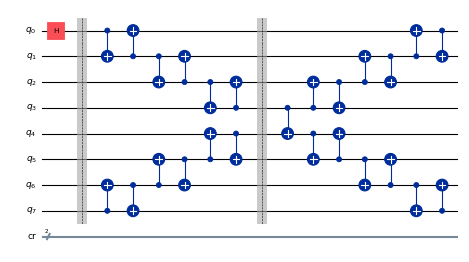

In [93]:
qc_uni.draw("mpl", fold=-1, scale=0.4)

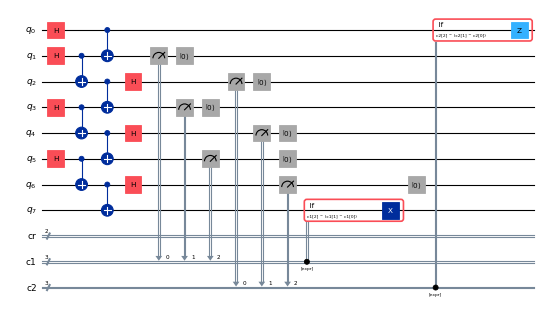

In [94]:
qc_dyn.draw("mpl", fold=-1, scale=0.4)

## Step 2 — Topology-aware qubit assignment (Problem 2.1)

| Topology | Bus strategy |
|---|---|
| **1D line** | Logical order `q0 — anc₁ — … — ancₙ — qₜ` |
| **2D square (`ibm_miami`)** | `shortest_path(backend, control, target)` on FakeMiami |
| **Heavy-hex (`ibm_yonsei`)** | Same on FakeBrisbane (ibm_yonsei proxy) |

`distance n = len(shortest_path) - 2`.

In [72]:
def find_connected_chain(coupling_map: CouplingMap, length: int) -> list[int]:
    num = coupling_map.size()
    neighbors = {i: set() for i in range(num)}
    for u, v in coupling_map.get_edges():
        neighbors[u].add(v)
        neighbors[v].add(u)

    found: list[int] = []

    def dfs(path: list[int], visited: set[int]) -> bool:
        nonlocal found
        if len(path) >= length:
            found = path[:length]
            return True
        for nbr in sorted(neighbors[path[-1]]):
            if nbr in visited:
                continue
            visited.add(nbr)
            path.append(nbr)
            if dfs(path, visited):
                return True
            path.pop()
            visited.remove(nbr)
        return False

    for start in range(num):
        if dfs([start], {start}):
            return found
    raise ValueError(f"No connected chain of length {length} on this coupling map")


def make_topology_backends():
    backends = {}

    line = CouplingMap.from_line(65)
    backends["1D line"] = GenericBackendV2(
        num_qubits=65,
        coupling_map=line,
        basis_gates=["cx", "rz", "sx", "x", "id"],
    )

    backends["2D square (ibm_miami)"] = backend_miami
    backends["heavy-hex (ibm_yonsei)"] = backend_yonsei

    return backends


TOPO_BACKENDS = make_topology_backends()
print("Topologies:", list(TOPO_BACKENDS))


Topologies: ['1D line', '2D square (ibm_miami)', 'heavy-hex (ibm_yonsei)']


In [73]:
def count_2q_gates(qc: QuantumCircuit) -> int:
    twoq = {"cx", "cz", "cy", "ch", "cp", "ecr", "rzz", "rxx", "ryy"}
    ops = qc.count_ops()
    return sum(ops.get(g, 0) for g in twoq)


def profile_logical(qc: QuantumCircuit) -> dict:
    ops = qc.count_ops()
    return {
        "num_qubits": qc.num_qubits,
        "depth": qc.depth(),
        "depth_2q": qc.depth(lambda inst: inst.operation.num_qubits == 2),
        "count_2q": count_2q_gates(qc),
        "measure": ops.get("measure", 0),
        "if_else": ops.get("if_else", 0),
        "swap": ops.get("swap", 0),
    }


def enable_dynamic_transpile(backend) -> None:
    if "if_else" not in backend.target.operation_names:
        backend.target.add_instruction(IfElseOp, name="if_else")
    if "reset" not in backend.target.operation_names:
        backend.target.add_instruction(Reset, name="reset")


def profile_transpiled(qc: QuantumCircuit, backend, *, chain: list[int] | None = None) -> dict:
    enable_dynamic_transpile(backend)
    if chain is not None:
        layout = Layout({qc.qubits[i]: chain[i] for i in range(qc.num_qubits)})
        pm = generate_preset_pass_manager(
            optimization_level=1, backend=backend, initial_layout=layout
        )
    else:
        pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    tqc = pm.run(qc)
    ops = tqc.count_ops()
    return {
        "num_qubits": tqc.num_qubits,
        "depth": tqc.depth(),
        "depth_2q": tqc.depth(lambda inst: inst.operation.num_qubits == 2),
        "count_2q": count_2q_gates(tqc),
        "measure": ops.get("measure", 0),
        "if_else": ops.get("if_else", 0),
        "swap": ops.get("swap", 0),
    }


def assign_chain_for_topology(topology: str, backend, n_logical: int) -> list[int]:
    if topology == "1D line":
        return list(range(n_logical))
    return find_connected_chain(backend.coupling_map, n_logical)


### Hardware layout mapping (Problem 2.1)

Given a **backend** and two physical qubits (**control**, **target**) for the long-range CNOT:

1. `shortest_path(backend, control, target)` — BFS shortest path on the coupling graph
2. `bus_chain_for_endpoints(...)` — ancilla bus = interior nodes; `distance n = len(path) - 2`
3. Transpile with that **initial layout**, then `plot_circuit_layout(..., view="physical", qubit_coordinates=None)`

In [74]:
def shortest_path(backend, qubit_a: int, qubit_b: int) -> list[int]:
    """Shortest path between two physical qubits on the backend coupling graph."""
    if qubit_a == qubit_b:
        return [qubit_a]

    coupling_map = backend.coupling_map
    neighbors: dict[int, set[int]] = {i: set() for i in range(coupling_map.size())}
    for u, v in coupling_map.get_edges():
        neighbors[u].add(v)
        neighbors[v].add(u)

    from collections import deque

    queue = deque([[qubit_a]])
    visited = {qubit_a}

    while queue:
        path = queue.popleft()
        node = path[-1]
        if node == qubit_b:
            return path
        for nbr in sorted(neighbors[node]):
            if nbr in visited:
                continue
            visited.add(nbr)
            queue.append(path + [nbr])

    raise ValueError(
        f"No path between physical qubits {qubit_a} and {qubit_b} on {backend.name}"
    )


def graph_hop_distance(backend, qubit_a: int, qubit_b: int) -> int:
    """Number of coupler hops (edges) on the shortest path."""
    return len(shortest_path(backend, qubit_a, qubit_b)) - 1


def bus_chain_for_endpoints(backend, control: int, target: int) -> tuple[list[int], int]:
    """Bus chain for long-range CNOT: control → ancillas → target.

    Returns (physical_chain, distance_n) where distance_n = len(chain) - 2.
    """
    chain = shortest_path(backend, control, target)
    if len(chain) < 2:
        raise ValueError("Need distinct control and target qubits")
    return chain, len(chain) - 2


def transpile_with_bus_layout(
    qc: QuantumCircuit,
    backend,
    chain: list[int],
    *,
    optimization_level: int = 1,
) -> QuantumCircuit:
    enable_dynamic_transpile(backend)
    layout = Layout({qc.qubits[i]: chain[i] for i in range(qc.num_qubits)})
    pm = generate_preset_pass_manager(
        optimization_level=optimization_level,
        backend=backend,
        initial_layout=layout,
    )
    return pm.run(qc)


def print_bus_assignment(chain: list[int], distance: int) -> None:
    print(
        f"distance n={distance}  |  bus chain length {len(chain)}  |  graph hops {len(chain) - 1}"
    )
    print(f"  control q0      → physical {chain[0]}")
    if distance > 0:
        print(f"  ancilla bus     → physical {chain[1:-1]}")
    print(f"  target q_{{n+1}} → physical {chain[-1]}")


#### 2D square grid — physical layout (`ibm_miami` / FakeMiami)

Shortest-path bus between two chosen physical qubits.

In [75]:
backend = backend_miami
control_qubit, target_qubit = 0, 7

chain_sq, distance_sq = bus_chain_for_endpoints(backend, control_qubit, target_qubit)
print_bus_assignment(chain_sq, distance_sq)
print(f"shortest path: {chain_sq}")

core_dyn = lrcx(distance_sq, prep_barrier=False, pre_measure_barrier=False)
core_uni = cnot_unitary_swap(distance_sq)

isa_dyn = transpile_with_bus_layout(core_dyn, backend, chain_sq)
isa_uni = transpile_with_bus_layout(core_uni, backend, chain_sq)

print(f"dynamic 2Q depth: {isa_dyn.depth(lambda x: x.operation.num_qubits == 2)}")
print(f"unitary 2Q depth: {isa_uni.depth(lambda x: x.operation.num_qubits == 2)}")


distance n=6  |  bus chain length 8  |  graph hops 7
  control q0      → physical 0
  ancilla bus     → physical [1, 2, 3, 4, 5, 6]
  target q_{n+1} → physical 7
shortest path: [0, 1, 2, 3, 4, 5, 6, 7]
dynamic 2Q depth: 2
unitary 2Q depth: 13


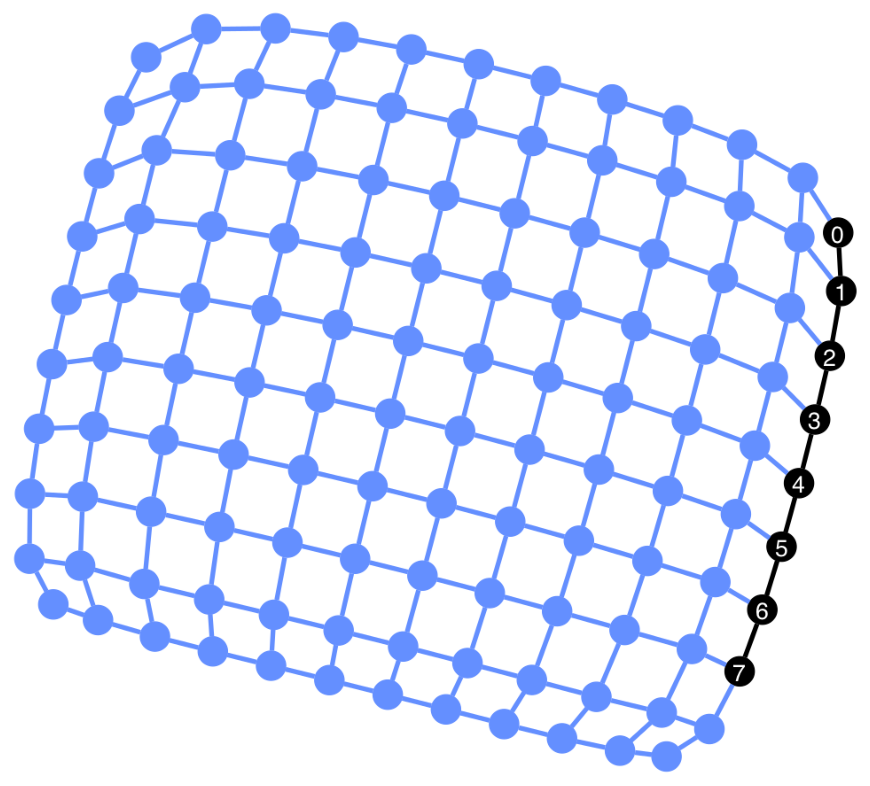

In [76]:
plot_circuit_layout(circuit=isa_dyn, backend=backend, view="physical", qubit_coordinates=None)


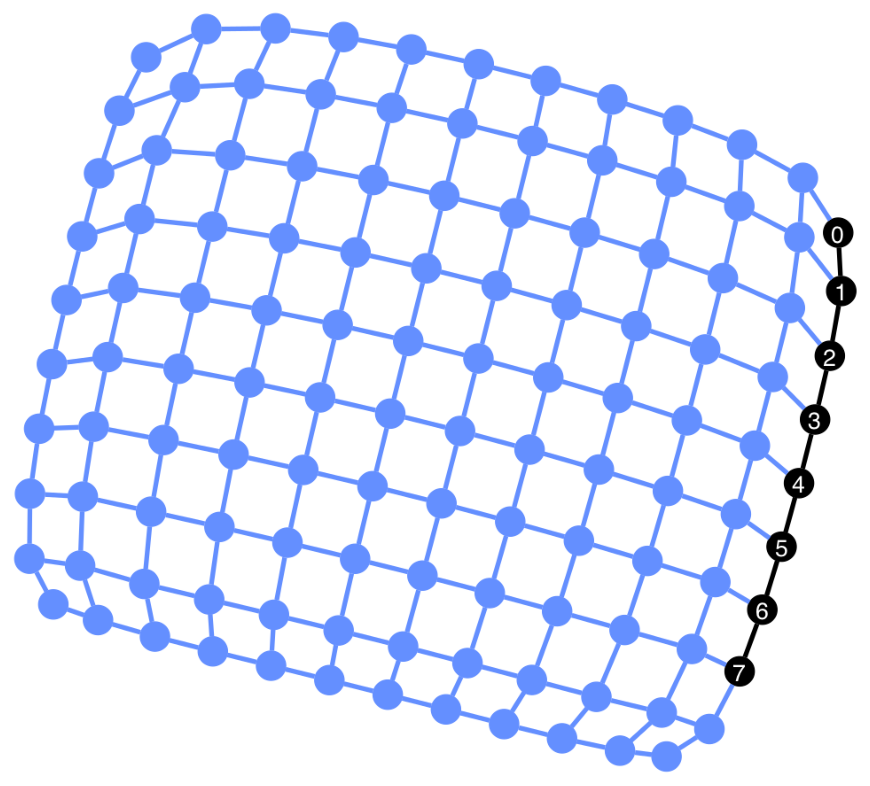

In [77]:
# Note: set qubit_coordinates=None to use the backend default gate-map layout.
plot_circuit_layout(circuit=isa_uni, backend=backend, view="physical", qubit_coordinates=None)


#### IBM heavy-hex — physical layout (`ibm_yonsei` / FakeBrisbane)

Same shortest-path workflow on the yonsei proxy backend.

In [78]:
backend = backend_yonsei
control_qubit, target_qubit = 0, 7

chain_hx, distance_hx = bus_chain_for_endpoints(backend, control_qubit, target_qubit)
print_bus_assignment(chain_hx, distance_hx)
print(f"shortest path: {chain_hx}")

core_dyn_hx = lrcx(distance_hx, prep_barrier=False, pre_measure_barrier=False)
core_uni_hx = cnot_unitary_swap(distance_hx)

isa_dyn_hx = transpile_with_bus_layout(core_dyn_hx, backend, chain_hx)
isa_uni_hx = transpile_with_bus_layout(core_uni_hx, backend, chain_hx)

print(f"dynamic 2Q depth: {isa_dyn_hx.depth(lambda x: x.operation.num_qubits == 2)}")
print(f"unitary 2Q depth: {isa_uni_hx.depth(lambda x: x.operation.num_qubits == 2)}")


distance n=6  |  bus chain length 8  |  graph hops 7
  control q0      → physical 0
  ancilla bus     → physical [1, 2, 3, 4, 5, 6]
  target q_{n+1} → physical 7
shortest path: [0, 1, 2, 3, 4, 5, 6, 7]
dynamic 2Q depth: 2
unitary 2Q depth: 13


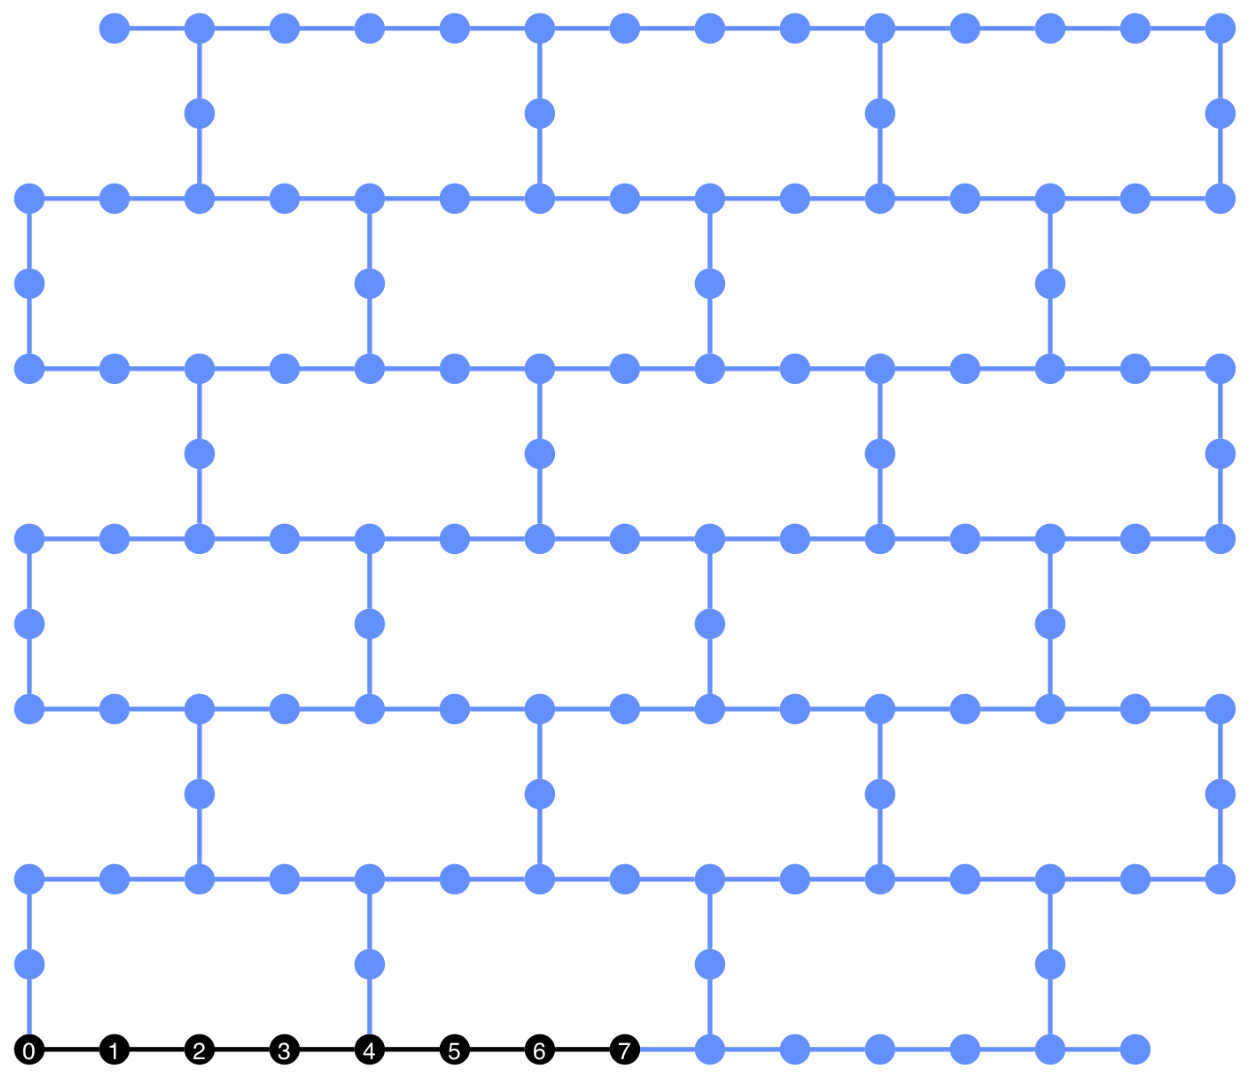

In [79]:
plot_circuit_layout(circuit=isa_dyn_hx, backend=backend, view="physical", qubit_coordinates=None)


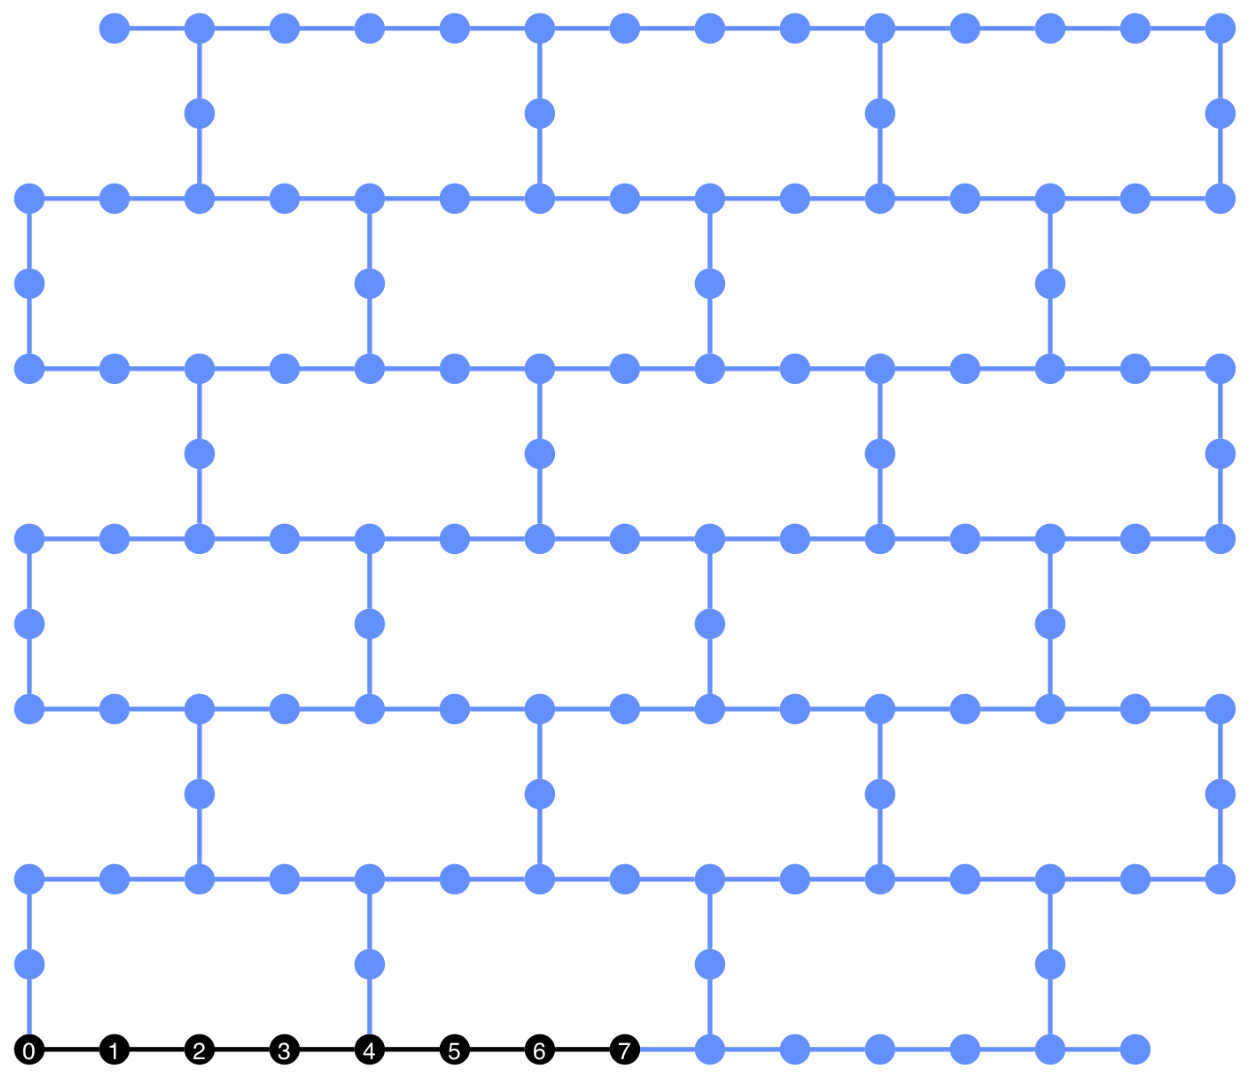

In [80]:
plot_circuit_layout(circuit=isa_uni_hx, backend=backend, view="physical", qubit_coordinates=None)


## Step 4 — Resource comparison vs distance (Problem 2.2)

For each topology we compare:

1. **Dynamic LRCX** with explicit bus layout (`chain` mapping)
2. **Unitary SWAP** manual circuit + transpiler
3. **Unitary default transpiler** (no manual SWAP, routing only)

Metrics: two-qubit gate count, 2Q depth, mid-circuit measurements (`if_else` proxy for dynamic).


In [81]:
DISTANCES = [0, 1, 2, 3, 6, 11, 16]
rows = []

for topology, backend in TOPO_BACKENDS.items():
    for distance in DISTANCES:
        n_logical = distance + 2
        try:
            chain = assign_chain_for_topology(topology, backend, n_logical)
        except ValueError as exc:
            print(f"skip {topology} distance={distance}: {exc}")
            continue

        dyn_core = lrcx(distance, prep_barrier=False, pre_measure_barrier=False)
        uni_core = cnot_unitary_swap(distance)

        dyn_prof = profile_logical(dyn_core)
        try:
            dyn_prof = profile_transpiled(dyn_core, backend, chain=chain)
        except Exception:
            pass

        uni_swap_prof = profile_transpiled(uni_core, backend, chain=chain)
        uni_auto_prof = profile_transpiled(uni_core, backend, chain=None)

        for variant, prof in [
            ("dynamic", dyn_prof),
            ("unitary_swap+layout", uni_swap_prof),
            ("unitary_transpiler", uni_auto_prof),
        ]:
            rows.append(
                {
                    "topology": topology,
                    "distance": distance,
                    "variant": variant,
                    **prof,
                }
            )

df_resources = pd.DataFrame(rows)
df_resources


,topology,distance,variant,num_qubits,depth,depth_2q,count_2q,measure,if_else,swap
0,1D line,0,dynamic,65,4,1,1,0,0,0
1,1D line,0,unitary_swap+layout,65,4,3,1,0,0,0
2,1D line,0,unitary_transpiler,65,4,3,1,0,0,0
3,1D line,1,dynamic,65,10,2,2,1,1,0
4,1D line,1,unitary_swap+layout,65,8,5,5,0,0,0
...,...,...,...,...,...,...,...,...,...,...
58,heavy-hex (ibm_yonsei),11,unitary_swap+layout,127,91,25,45,0,0,0
59,heavy-hex (ibm_yonsei),11,unitary_transpiler,127,91,25,45,0,0,0
60,heavy-hex (ibm_yonsei),16,dynamic,127,13,2,17,16,2,0
61,heavy-hex (ibm_yonsei),16,unitary_swap+layout,127,123,33,65,0,0,0


In [82]:
# Problem 2.2 — Unitary vs dynamic: gate count, depth, mid-circuit measurements
# (2D square & heavy-hex only — Problem 2.1 does not include 1D line)
VARIANT_LABELS = {
    "dynamic": "dynamic",
    "unitary_swap+layout": "unitary",
}

METRICS = [
    ("count_2q", "2Q gate count"),
    ("depth_2q", "2Q depth"),
    ("measure", "mid-circuit measurements"),
]

df_p2_2 = (
    df_resources[
        df_resources["variant"].isin(VARIANT_LABELS)
        & ~df_resources["topology"].str.startswith("1D line")
    ]
    .assign(variant=lambda d: d["variant"].map(VARIANT_LABELS))
    .sort_values(["topology", "distance", "variant"])
)

report_tables = []
for metric_col, metric_name in METRICS:
    table = (
        df_p2_2.pivot(index=["topology", "distance"], columns="variant", values=metric_col)
        .rename_axis(None, axis=1)
        .reindex(columns=["dynamic", "unitary"])
    )
    table.columns = pd.MultiIndex.from_product([[metric_name], table.columns])
    report_tables.append(table)

df_report_p2_2 = pd.concat(report_tables, axis=1)
df_report_p2_2

2Q gate count         2Q depth          \
                                      dynamic unitary  dynamic unitary   
topology               distance                                          
2D square (ibm_miami)  0                    1       1        1       3   
                       1                    2       5        2       5   
                       2                    3       9        2       5   
                       3                    4      13        2       9   
                       6                    7      25        2      13   
                       11                  12      45        2      25   
                       16                  17      65        2      33   
heavy-hex (ibm_yonsei) 0                    1       1        1       3   
                       1                    2       5        2       5   
                       2                    3       9        2       5   
                       3                    4      13        2       9   
                       6                    7      25        2      13   
                       11                  12      45        2      25   
                       16                  17      65        2      33   

                                mid-circuit measurements          
                                                 dynamic unitary  
topology               distance                                   
2D square (ibm_miami)  0                               0       0  
                       1                               1       0  
                       2                               2       0  
                       3                               3       0  
                       6                               6       0  
                       11                             11       0  
                       16                             16       0  
heavy-hex (ibm_yonsei) 0                               0       0  
                       1                               1       0  
                       2                               2       0  
                       3                               3       0  
                       6                               6       0  
                       11                             11       0  
                       16                             16       0

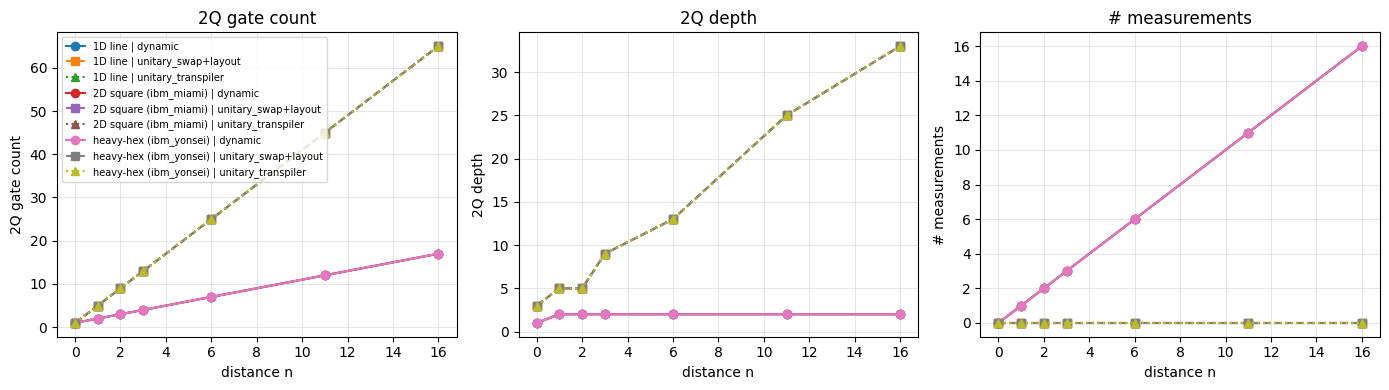

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [("count_2q", "2Q gate count"), ("depth_2q", "2Q depth"), ("measure", "# measurements")]

for ax, (col, title) in zip(axes, metrics):
    for topology in df_resources["topology"].unique():
        sub = df_resources[df_resources["topology"] == topology]
        for variant, style in [
            ("dynamic", "o-"),
            ("unitary_swap+layout", "s--"),
            ("unitary_transpiler", "^:"),
        ]:
            s = sub[sub["variant"] == variant]
            if s.empty:
                continue
            ax.plot(s["distance"], s[col], style, label=f"{topology} | {variant}")
    ax.set_xlabel("distance n")
    ax.set_ylabel(title)
    ax.grid(alpha=0.3)
    ax.set_title(title)

axes[0].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()


## Step 5 — Schematic bus-chain view (supplement)

For a compact schematic of the chosen bus paths (without full transpiled ISA layout), see the plots below. Detailed **physical** mappings are in Step 2.1 above.


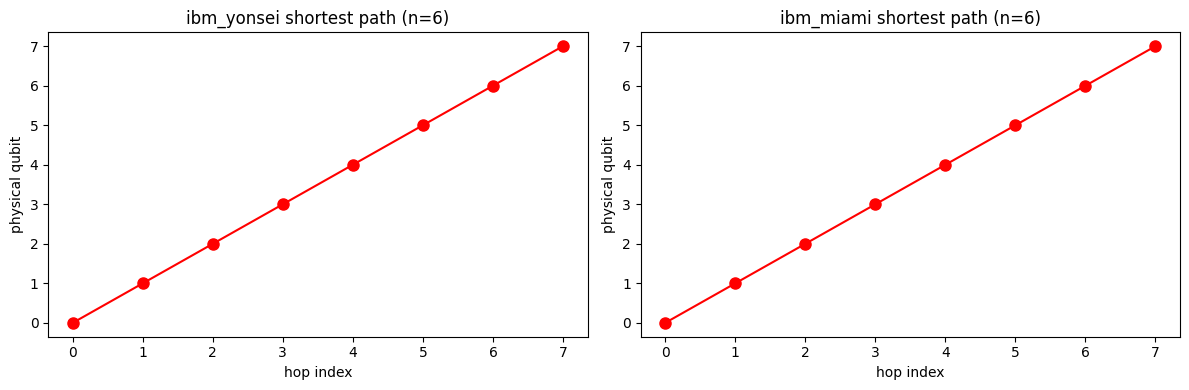

ibm_miami: [0, 1, 2, 3, 4, 5, 6, 7]
ibm_yonsei: [0, 1, 2, 3, 4, 5, 6, 7]


In [84]:
def plot_bus_chain(chain, rows=None, cols=None, *, ax, title: str):
    if rows is not None and cols is not None:
        xs = [q % cols for q in chain]; ys = [q // cols for q in chain]
        ax.scatter(xs, ys, c="steelblue", s=80, zorder=3)
        for i in range(len(chain)-1):
            ax.plot([xs[i], xs[i+1]], [ys[i], ys[i+1]], "crimson", linewidth=2, zorder=2)
        ax.set_xticks(range(cols)); ax.set_yticks(range(rows)); ax.grid(alpha=0.3)
    else:
        ax.plot(range(len(chain)), chain, "o-r", markersize=8)
        ax.set_xlabel("hop index"); ax.set_ylabel("physical qubit")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
chain_sq, n_sq = bus_chain_for_endpoints(backend_miami, 0, 7)
chain_hx, n_hx = bus_chain_for_endpoints(backend_yonsei, 0, 7)
plot_bus_chain(chain_hx, ax=axes[0], title=f"ibm_yonsei shortest path (n={n_hx})")
plot_bus_chain(chain_sq, ax=axes[1], title=f"ibm_miami shortest path (n={n_sq})")
plt.tight_layout(); plt.show()
print("ibm_miami:", chain_sq)
print("ibm_yonsei:", chain_hx)


## Discussion (Problem 2.1–2.2)

**Square grid:** A snake path uses only nearest-neighbor grid edges; ancillas fill every hop between control and target. SWAP overhead is minimal when the path follows the grid.

**Heavy-hex:** Logical bus qubits map to a DFS-found connected chain; non-local index gaps are fine as long as couplers exist. Dynamic circuits avoid routing SWAPs but pay **mid-circuit measurement + feed-forward** latency.

**Unitary vs dynamic:** At small `n`, unitary SWAP depth is modest. As `n` grows, unitary 2Q depth scales O(n) while dynamic 2Q depth stays O(1); the crossover depends on `λ_idle`, `λ_CNOT`, `λ_meas` — analyzed in **Problem 3** (last section of this notebook).

## References

1. 2026 Quantum Hackathon — Dynamic Circuits (지정문제 4)
2. E. Bäumer *et al.*, PRX Quantum **5**, 030339 (2024)
3. IBM Quantum tutorial: *Long-range entanglement with dynamic circuits*
